# Final Results Analysis

## Notebook Objective

This notebook is the central results notebook for the final paper and report. It collects the dataset summaries, feature engineering summaries, model comparisons, training curves, confusion matrices, and final tables used to explain the project results.

The project predicts flight delay severity using a real-world 2023-2025 flight dataset with approximately 21 million raw records from the U.S. Bureau of Transportation Statistics (BTS) TranStats Airline On-Time Performance Data. The final target has 3 classes:

- 0 - On time: arrival delay of 15 minutes or less.
- 1 - Delay: arrival delay from 16 to 90 minutes.
- 2 - Long delay: arrival delay greater than 90 minutes.

The original target idea had 5 classes, but that created stronger class imbalance. The 3-class version is more stable for training and easier to explain in an operational setting.


## Setup and Helper Imports

The first cells load the libraries used for tables, figures, metrics, and file handling. These imports support the analysis only; they do not retrain or modify any model.


In [1]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix
)

## Route Lookup Export

This cell creates a route lookup table from the model-ready dataset. The lookup connects each route with origin and destination airport information, distance, and number of flights.

This file is useful for the report because route-level features are important in the final models.


In [2]:
from pathlib import Path
import polars as pl

BASE_DIR = Path.cwd().parent
GENERATED_DIR = BASE_DIR / "data" / "generated"
PROCESSED_DIR = GENERATED_DIR / "processed"

model_base_path = GENERATED_DIR / "flights_2023_2025_model_base.parquet"
route_lookup_path = PROCESSED_DIR / "route_lookup.csv"

route_lookup = (
    pl.scan_parquet(model_base_path)
      .group_by([
          "ROUTE",
          "ORIGIN",
          "ORIGIN_CITY_NAME",
          "ORIGIN_STATE_ABR",
          "DEST",
          "DEST_CITY_NAME",
          "DEST_STATE_ABR"
      ])
      .agg([
          pl.col("DISTANCE").median().alias("DISTANCE"),
          pl.len().alias("num_flights")
      ])
      .sort("ROUTE")
      .collect()
)

route_lookup.write_csv(route_lookup_path)

print("Saved:", route_lookup_path)
print(route_lookup.shape)
route_lookup.head()

Saved: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\data\generated\processed\route_lookup.csv
(7519, 9)


ROUTE,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_ABR,DEST,DEST_CITY_NAME,DEST_STATE_ABR,DISTANCE,num_flights
str,str,str,str,str,str,str,f64,u32
"""ABE_ATL""","""ABE""","""Allentown/Bethlehem/Easton, PA""","""PA""","""ATL""","""Atlanta, GA""","""GA""",692.0,1990
"""ABE_BNA""","""ABE""","""Allentown/Bethlehem/Easton, PA""","""PA""","""BNA""","""Nashville, TN""","""TN""",685.0,308
"""ABE_CLT""","""ABE""","""Allentown/Bethlehem/Easton, PA""","""PA""","""CLT""","""Charlotte, NC""","""NC""",481.0,3115
"""ABE_DEN""","""ABE""","""Allentown/Bethlehem/Easton, PA""","""PA""","""DEN""","""Denver, CO""","""CO""",1539.0,187
"""ABE_FLL""","""ABE""","""Allentown/Bethlehem/Easton, PA""","""PA""","""FLL""","""Fort Lauderdale, FL""","""FL""",1041.0,299


The route lookup contains thousands of route combinations. This supports the idea that route is a high-cardinality feature and should be handled with embeddings instead of simple one-hot encoding.


## Project Output Paths

The notebook defines the main project folders and creates the output folders for paper tables and figures. All final report artifacts are saved under `paper_outputs`.


In [3]:
BASE_DIR = Path.cwd().parent

DATA_DIR = BASE_DIR / "data"
GENERATED_DIR = DATA_DIR / "generated"
PROCESSED_DIR = GENERATED_DIR / "processed"
RESULTS_DIR = BASE_DIR / "results"
MODELS_DIR = BASE_DIR / "models"

REPORT_DIR = BASE_DIR / "paper_outputs"
FIGURES_DIR = REPORT_DIR / "figures"
TABLES_DIR = REPORT_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("GENERATED_DIR:", GENERATED_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("TABLES_DIR:", TABLES_DIR)

BASE_DIR: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos
GENERATED_DIR: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\data\generated
PROCESSED_DIR: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\data\generated\processed
RESULTS_DIR: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\results
FIGURES_DIR: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\figures
TABLES_DIR: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\tables


## Utility Functions

These helper functions load JSON files, save CSV tables, save figures, format numbers, and attach class names to tables. They keep the rest of the notebook shorter and more consistent.


In [4]:
def load_json(path):
    path = Path(path)
    if not path.exists():
        print(f"Missing file: {path}")
        return None
    
    with open(path, "r") as f:
        return json.load(f)


def save_table(df, filename):
    output_path = TABLES_DIR / filename
    df.to_csv(output_path, index=False)
    print(f"Saved table: {output_path}")


def save_current_figure(filename):
    output_path = FIGURES_DIR / filename
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved figure: {output_path}")


def format_number(x):
    return f"{int(x):,}"


def add_class_names(df, class_col="delay_class", class_names=None):
    df = df.copy()
    df["class_name"] = df[class_col].astype(str).map(class_names)
    return df

## Loading Project Metadata

Metadata is loaded to recover the exact features and target labels used during training. This includes categorical features, numerical features, class names, and class weights.

Loading this information from saved files helps make sure the final analysis matches the preprocessing and model notebooks.


In [5]:
metadata = load_json(PROCESSED_DIR / "metadata.json")
category_cardinalities = load_json(PROCESSED_DIR / "category_cardinalities.json")
class_weights_dict = load_json(PROCESSED_DIR / "class_weights.json")

categorical_cols = metadata["categorical_cols"]
numeric_cols = metadata["numeric_cols"]
target_col = metadata["target_col"]
num_classes = metadata["num_classes"]
class_names = metadata["class_names"]

target_names = [class_names[str(i)] for i in range(num_classes)]

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)
print("Target column:", target_col)
print("Number of classes:", num_classes)
print("Class names:", class_names)
print("Class weights:", class_weights_dict)

Categorical columns: ['OP_UNIQUE_CARRIER', 'ORIGIN', 'ORIGIN_STATE_ABR', 'DEST', 'DEST_STATE_ABR', 'ROUTE', 'DEP_TIME_BLK', 'ARR_TIME_BLK']
Numeric columns: ['DISTANCE', 'CRS_DEP_MINUTES_OF_DAY', 'dep_time_sin', 'dep_time_cos', 'month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos', 'is_weekend']
Target column: delay_class
Number of classes: 3
Class names: {'0': 'On time', '1': 'Delay', '2': 'Long delay'}
Class weights: {'0': 0.4195488529623715, '1': 2.0804489830682193, '2': 7.3625845179253355}


The next cell checks that the notebook is using the final 3-class target. This avoids mixing results from the earlier 5-class version of the project.


In [6]:
assert num_classes == 3
assert target_names == ["On time", "Delay", "Long delay"]

print("Metadata validation passed.")

Metadata validation passed.


The metadata check passes, so all tables and figures in this notebook are based on the final 3-class target.


## Dataset Overview

This table summarizes the main datasets created during the project:

- The raw unified dataset contains the merged monthly flight files.
- The clean full dataset removes cancelled flights and rows without valid arrival delay.
- The model base dataset keeps only the features that can be used without data leakage.

This overview is important because the report should clearly show how the data changes from raw input to model-ready data.


In [7]:
dataset_files = {
    "Raw unified dataset": GENERATED_DIR / "flights_2023_2025_raw.parquet",
    "Clean full dataset": GENERATED_DIR / "flights_2023_2025_clean_full.parquet",
    "Model base dataset": GENERATED_DIR / "flights_2023_2025_model_base.parquet"
}

dataset_overview_rows = []

for name, path in dataset_files.items():
    if path.exists():
        scan = pl.scan_parquet(path)
        rows = scan.select(pl.len().alias("rows")).collect().item()
        cols = len(scan.collect_schema())
        
        dataset_overview_rows.append({
            "dataset": name,
            "rows": rows,
            "columns": cols,
            "file_path": str(path)
        })
    else:
        dataset_overview_rows.append({
            "dataset": name,
            "rows": None,
            "columns": None,
            "file_path": str(path)
        })

dataset_overview = pd.DataFrame(dataset_overview_rows)

save_table(dataset_overview, "table_01_dataset_overview.csv")

dataset_overview

Saved table: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\tables\table_01_dataset_overview.csv


,dataset,rows,columns,file_path
0,Raw unified dataset,20928599,35,c:\Users\of_de\Documents\ESCUELA\UP\8vo Semest...
1,Clean full dataset,20588154,43,c:\Users\of_de\Documents\ESCUELA\UP\8vo Semest...
2,Model base dataset,20588154,21,c:\Users\of_de\Documents\ESCUELA\UP\8vo Semest...


### Dataset Overview Interpretation

The raw dataset contains the original merged monthly records. The clean dataset removes invalid or cancelled flights that cannot be used for arrival delay modeling. The model-ready dataset keeps the same cleaned rows but reduces the columns to features that are available before the flight and the final target.


## Monthly Flight Distribution

Flights per month are checked to validate the dataset and to see how the data volume changes over time. This helps ensure that all months across the 2023-2025 period are represented and provides context for understanding the data distribution.


In [8]:
model_base_path = GENERATED_DIR / "flights_2023_2025_model_base.parquet"

monthly_counts = (
    pl.scan_parquet(model_base_path)
      .group_by("MONTH")
      .agg(pl.len().alias("num_flights"))
      .sort("MONTH")
      .collect()
      .to_pandas()
)

monthly_counts["percentage"] = (
    monthly_counts["num_flights"] / monthly_counts["num_flights"].sum() * 100
).round(2)

save_table(monthly_counts, "table_02_monthly_flight_counts.csv")

monthly_counts

Saved table: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\tables\table_02_monthly_flight_counts.csv


,MONTH,num_flights,percentage
0,1,1574836,7.65
1,2,1504492,7.31
2,3,1749247,8.50
3,4,1704914,8.28
4,5,1772229,8.61
5,6,1763548,8.57
6,7,1811807,8.80
7,8,1790178,8.70
8,9,1697477,8.24
9,10,1806087,8.77


The chart shows the same monthly counts visually. It helps identify whether some months have much larger or smaller volumes than others.


Saved figure: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\figures\figure_01_monthly_flight_counts.png


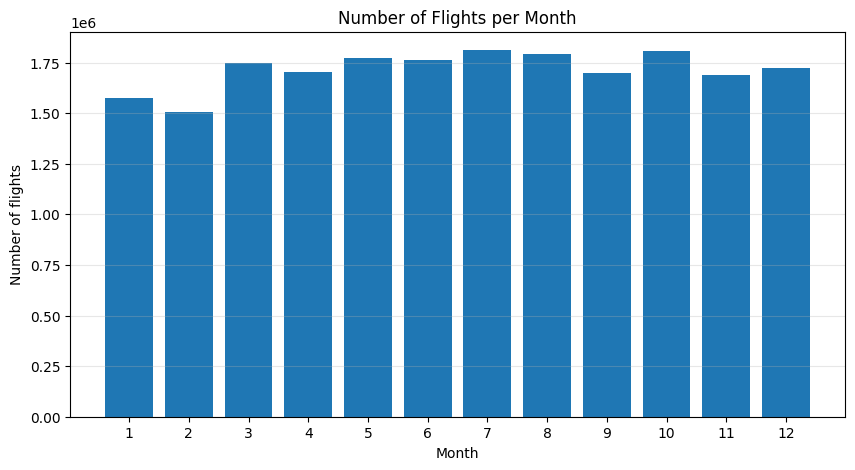

In [9]:
plt.figure(figsize=(10, 5))
plt.bar(monthly_counts["MONTH"], monthly_counts["num_flights"])
plt.xlabel("Month")
plt.ylabel("Number of flights")
plt.title("Number of Flights per Month")
plt.xticks(monthly_counts["MONTH"])
plt.grid(axis="y", alpha=0.3)
save_current_figure("figure_01_monthly_flight_counts.png")
plt.show()

### Monthly Distribution Interpretation

The monthly distribution helps validate the merged 2023-2025 dataset and highlights differences in data volume across months. These variations in monthly volume are expected when combining three years of data and provide context for understanding the dataset composition.


## Overall Class Distribution

The final target has three delay severity classes: `On time`, `Delay`, and `Long delay`. This table shows how many flights belong to each class.

Class imbalance is important here because most flights are on time. A model can get a high accuracy by predicting the majority class, so accuracy alone is not enough for evaluation.


In [10]:
overall_class_distribution = (
    pl.scan_parquet(model_base_path)
      .group_by(["delay_class", "delay_class_name"])
      .agg(pl.len().alias("count"))
      .with_columns(
          ((pl.col("count") / pl.col("count").sum()) * 100).round(4).alias("percentage")
      )
      .sort("delay_class")
      .collect()
      .to_pandas()
)

save_table(overall_class_distribution, "table_03_overall_class_distribution.csv")

overall_class_distribution

Saved table: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\tables\table_03_overall_class_distribution.csv


,delay_class,delay_class_name,count,percentage
0,0,On time,16357376,79.4504
1,1,Delay,3298671,16.0222
2,2,Long delay,932107,4.5274


The count chart makes the imbalance easy to see. It shows that the `On time` class is much larger than the delayed classes.


Saved figure: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\figures\figure_02_overall_class_distribution.png


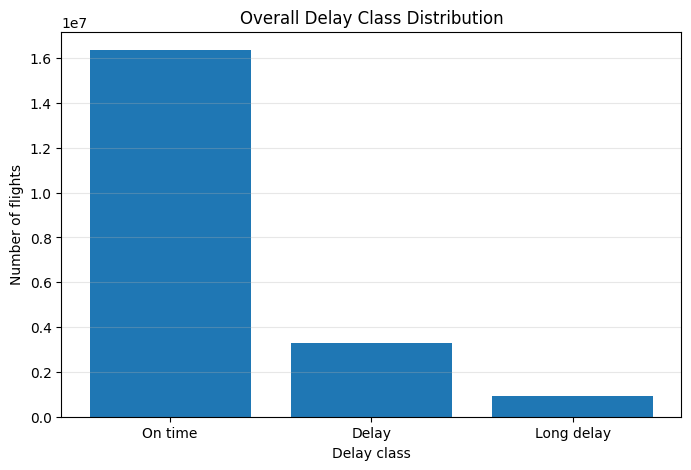

In [11]:
plt.figure(figsize=(8, 5))
plt.bar(
    overall_class_distribution["delay_class_name"],
    overall_class_distribution["count"]
)
plt.xlabel("Delay class")
plt.ylabel("Number of flights")
plt.title("Overall Delay Class Distribution")
plt.grid(axis="y", alpha=0.3)
save_current_figure("figure_02_overall_class_distribution.png")
plt.show()

The percentage chart is useful for reporting because it summarizes the same class distribution in a compact way.


Saved figure: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\figures\figure_03_overall_class_distribution_percentage.png


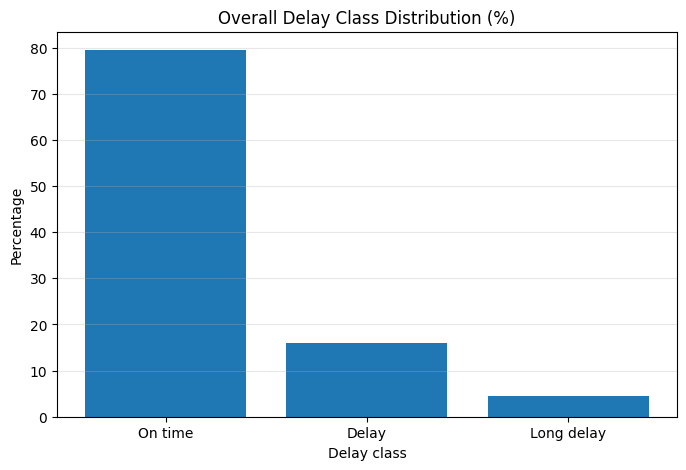

In [12]:
plt.figure(figsize=(8, 5))
plt.bar(
    overall_class_distribution["delay_class_name"],
    overall_class_distribution["percentage"]
)
plt.xlabel("Delay class")
plt.ylabel("Percentage")
plt.title("Overall Delay Class Distribution (%)")
plt.grid(axis="y", alpha=0.3)
save_current_figure("figure_03_overall_class_distribution_percentage.png")
plt.show()

### Class Distribution Interpretation

`On time` is the majority class, `Delay` is the second most frequent class, and `Long delay` is the minority class. This imbalance justifies using Macro F1 and per-class metrics instead of selecting models by accuracy alone.


## Train, Validation, and Test Split Distribution

The split uses a stratified random strategy to preserve class proportions while allowing seasonal patterns from all three years to be represented in each split:

- Train: 70% of all data.
- Validation: 15% of all data.
- Test: 15% of all data.

The split is stratified by the target class (On time, Delay, Long delay) to maintain balanced class representation across train, validation, and test sets. This approach ensures that each set contains examples from across the full 2023-2025 period while preserving class distributions.


In [13]:
split_distribution_path = PROCESSED_DIR / "split_class_distribution.csv"

split_distribution = pd.read_csv(split_distribution_path)

split_distribution["class_name"] = split_distribution["delay_class"].astype(str).map(class_names)

split_distribution = split_distribution[
    ["split", "delay_class", "class_name", "count", "percentage"]
].sort_values(["split", "delay_class"])

save_table(split_distribution, "table_04_split_class_distribution.csv")

split_distribution

Saved table: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\tables\table_04_split_class_distribution.csv


,split,delay_class,class_name,count,percentage
6,test,0,On time,2453607,79.4504
7,test,1,Delay,494801,16.0222
8,test,2,Long delay,139816,4.5274
0,train,0,On time,11450162,79.4504
1,train,1,Delay,2309070,16.0222
2,train,2,Long delay,652475,4.5274
3,validation,0,On time,2453607,79.4504
4,validation,1,Delay,494800,16.0222
5,validation,2,Long delay,139816,4.5274


In [14]:
pivot_split_percentage = split_distribution.pivot(
    index="class_name",
    columns="split",
    values="percentage"
).loc[target_names]

pivot_split_percentage

split,test,train,validation
class_name,,,
On time,79.4504,79.4504,79.4504
Delay,16.0222,16.0222,16.0222
Long delay,4.5274,4.5274,4.5274


The split distribution chart compares class percentages across train, validation, and test. This helps verify that the evaluation splits are reasonably comparable.


Saved figure: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\figures\figure_04_class_distribution_by_split.png


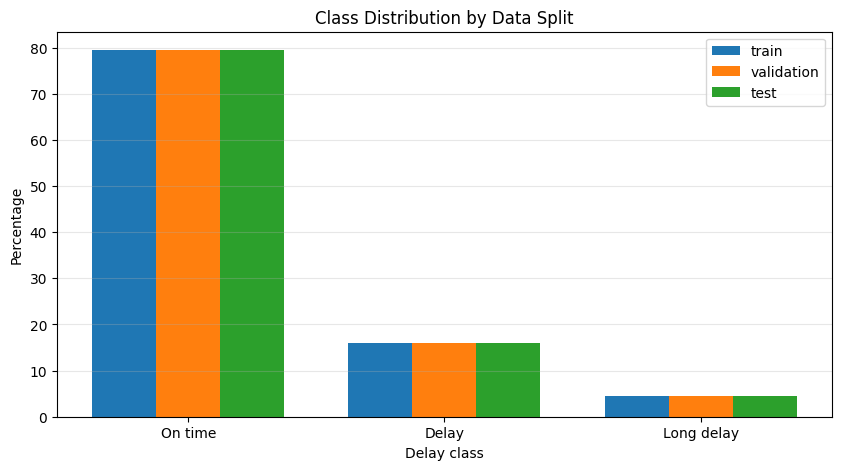

In [15]:
x = np.arange(len(target_names))
width = 0.25

plt.figure(figsize=(10, 5))

for idx, split in enumerate(["train", "validation", "test"]):
    plt.bar(
        x + (idx - 1) * width,
        pivot_split_percentage[split],
        width,
        label=split
    )

plt.xlabel("Delay class")
plt.ylabel("Percentage")
plt.title("Class Distribution by Data Split")
plt.xticks(x, target_names)
plt.legend()
plt.grid(axis="y", alpha=0.3)
save_current_figure("figure_04_class_distribution_by_split.png")
plt.show()

### Split Distribution Interpretation

The class proportions are preserved across train, validation, and test due to the stratified sampling strategy. This ensures that the model is evaluated on representative data with balanced class distributions, which is important for assessing how the model will perform on new unseen data.


## Delay Patterns by Airline, Airport, and Route

The next summaries look at average delay patterns by carrier, origin airport, and route. These analyses help understand the data before interpreting the models.

The wording is important: these groups are associated with different average delays, but this analysis does not prove that a carrier, airport, or route directly causes delays.

### Airline Delay Summary

This table ranks carriers by average arrival delay minutes.


In [16]:
carrier_summary_path = GENERATED_DIR / "carrier_delay_summary.csv"

carrier_summary = pd.read_csv(carrier_summary_path)

carrier_summary_sorted = carrier_summary.sort_values(
    "avg_delay_minutes",
    ascending=False
)

save_table(carrier_summary_sorted, "table_05_carrier_delay_summary.csv")

carrier_summary_sorted.head(15)

Saved table: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\tables\table_05_carrier_delay_summary.csv


,OP_UNIQUE_CARRIER,num_flights,avg_delay_minutes,median_delay_minutes,delayed_percentage
0,F9,571133,24.58,0.0,28.56
1,B6,730301,23.27,0.0,27.13
2,AA,2847015,22.22,0.0,24.28
3,G4,359199,21.46,0.0,23.53
4,OH,651427,19.93,0.0,21.69
5,NK,705662,19.01,0.0,24.47
6,OO,2223949,16.18,0.0,18.24
7,UA,2252227,15.86,0.0,20.00
8,DL,2983204,13.78,0.0,17.25
9,MQ,791847,13.66,0.0,19.47


The carrier chart shows the top carriers by average arrival delay. This supports including carrier as a categorical feature, because delay patterns can vary by airline.


Saved figure: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\figures\figure_05_top_carriers_avg_delay.png


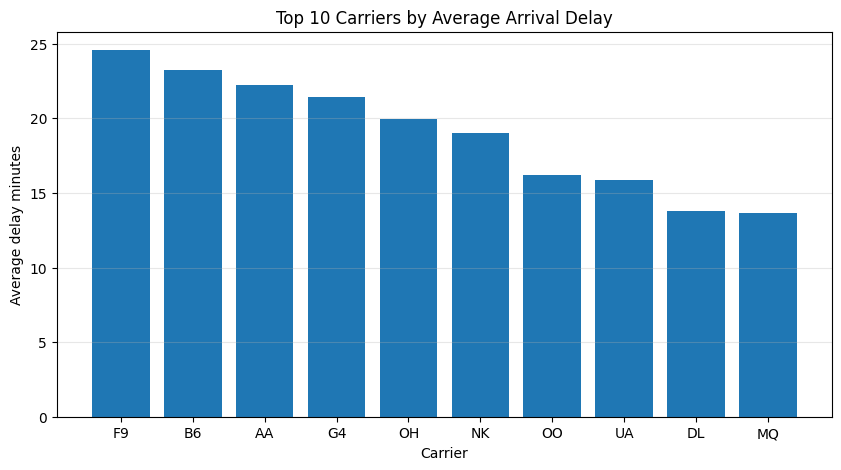

In [17]:
top_carriers = carrier_summary_sorted.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_carriers["OP_UNIQUE_CARRIER"], top_carriers["avg_delay_minutes"])
plt.xlabel("Carrier")
plt.ylabel("Average delay minutes")
plt.title("Top 10 Carriers by Average Arrival Delay")
plt.grid(axis="y", alpha=0.3)
save_current_figure("figure_05_top_carriers_avg_delay.png")
plt.show()

### Airline Summary Interpretation

Some carriers are associated with higher average arrival delay in this dataset. This does not prove causation, but it suggests that carrier information contains useful predictive signal.


### Origin Airport Delay Summary

This table ranks origin airports by average delay minutes. Airports can have different operational conditions, but this table should be interpreted as descriptive analysis, not causation.


In [18]:
origin_summary_path = GENERATED_DIR / "origin_delay_summary.csv"

origin_summary = pd.read_csv(origin_summary_path)

origin_summary_sorted = origin_summary.sort_values(
    "avg_delay_minutes",
    ascending=False
)

save_table(origin_summary_sorted, "table_06_origin_delay_summary.csv")

origin_summary_sorted.head(15)

Saved table: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\tables\table_06_origin_delay_summary.csv


,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_ABR,num_flights,avg_delay_minutes,delayed_percentage
0,HTS,"Ashland, WV",WV,1340,40.99,41.42
1,USA,"Concord, NC",NC,2138,37.45,36.06
2,DEC,"Decatur, IL",IL,2333,33.98,21.17
3,SCK,"Stockton, CA",CA,1601,32.95,37.60
4,DDC,"Dodge City, KS",KS,1809,32.02,20.01
5,HOB,"Hobbs, NM",NM,1151,31.92,20.42
6,ASE,"Aspen, CO",CO,20556,31.29,30.90
7,PBG,"Plattsburgh, NY",NY,1392,30.74,29.60
8,TOL,"Toledo, OH",OH,1155,29.22,30.48
9,PRC,"Prescott, AZ",AZ,2222,29.01,22.41


The origin airport chart shows where average delays are higher in this dataset. These differences support using origin airport and origin state as model features.


Saved figure: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\figures\figure_06_top_origin_airports_avg_delay.png


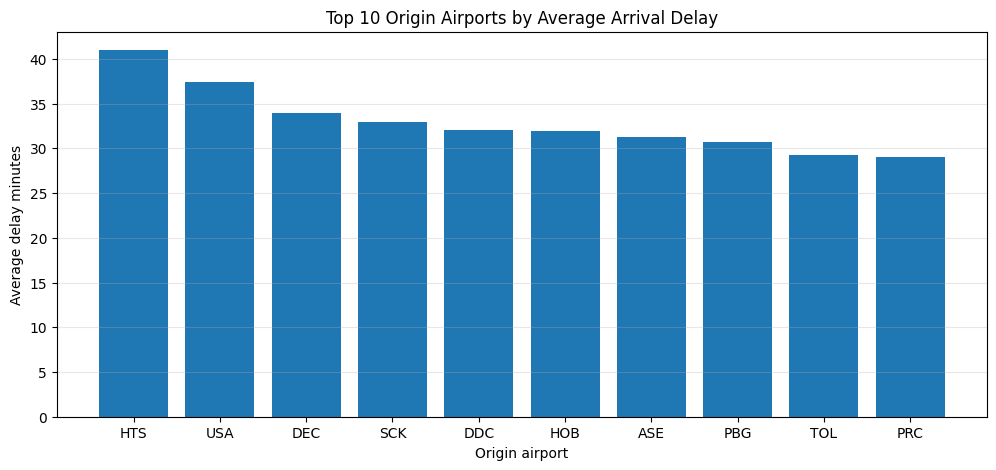

In [19]:
top_origins = origin_summary_sorted.head(10)

plt.figure(figsize=(12, 5))
plt.bar(top_origins["ORIGIN"], top_origins["avg_delay_minutes"])
plt.xlabel("Origin airport")
plt.ylabel("Average delay minutes")
plt.title("Top 10 Origin Airports by Average Arrival Delay")
plt.grid(axis="y", alpha=0.3)
save_current_figure("figure_06_top_origin_airports_avg_delay.png")
plt.show()

### Origin Airport Summary Interpretation

Some origin airports show higher average delay minutes. This suggests that airport-related features may help the model capture operational patterns that are not visible from time or distance alone.


### Route Delay Summary

This table ranks routes by average delay minutes. Route-level information is useful because delays can be associated with specific origin-destination combinations.


In [20]:
route_summary_path = GENERATED_DIR / "route_delay_summary.csv"

route_summary = pd.read_csv(route_summary_path)

route_summary_sorted = route_summary.sort_values(
    "avg_delay_minutes",
    ascending=False
)

save_table(route_summary_sorted, "table_07_route_delay_summary.csv")

route_summary_sorted.head(15)

Saved table: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\tables\table_07_route_delay_summary.csv


,ROUTE,num_flights,avg_delay_minutes,delayed_percentage
0,SNA_PVU,1058,59.35,37.81
1,LEX_SFB,639,53.20,44.60
2,USA_FLL,572,50.19,40.03
3,DFW_ALB,726,48.36,49.17
4,BUR_JFK,790,47.48,46.71
5,JAC_DFW,1931,46.99,27.81
6,ABQ_JFK,626,44.69,36.58
7,HTS_PIE,523,43.41,39.96
8,USA_SFB,588,43.25,40.48
9,EYW_PHL,1250,43.10,32.00


The route chart shows that some routes are associated with higher average delays. This supports using a route feature and motivates embedding-based models that can learn route patterns.


Saved figure: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\figures\figure_07_top_routes_avg_delay.png


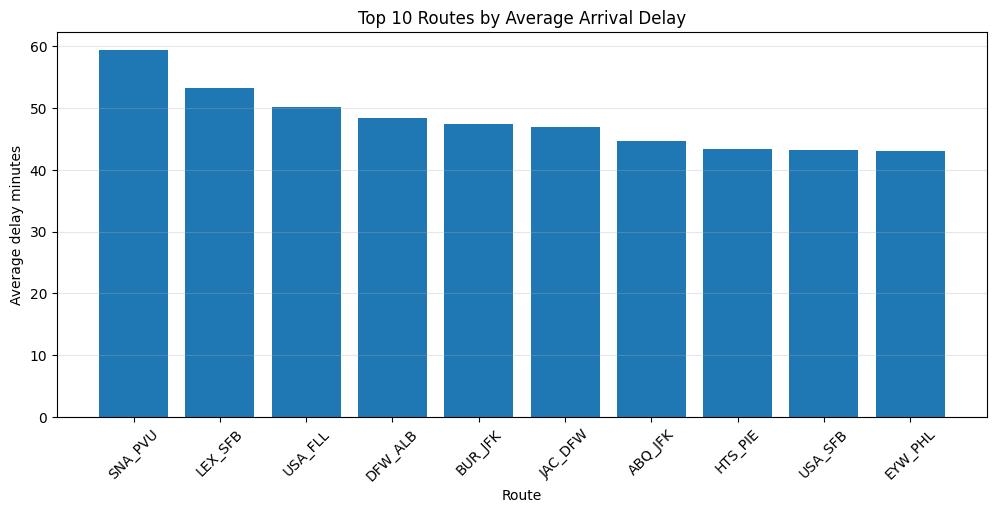

In [21]:
top_routes = route_summary_sorted.head(10)

plt.figure(figsize=(12, 5))
plt.bar(top_routes["ROUTE"], top_routes["avg_delay_minutes"])
plt.xlabel("Route")
plt.ylabel("Average delay minutes")
plt.title("Top 10 Routes by Average Arrival Delay")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
save_current_figure("figure_07_top_routes_avg_delay.png")
plt.show()

### Route Summary Interpretation

Some routes have noticeably higher average delay. Since routes combine origin and destination information, this pattern supports using route embeddings and more expressive models.


## Feature Engineering Summary

The project uses two main feature groups:

- Categorical features encoded as integer IDs for embedding layers.
- Numerical features scaled using `StandardScaler`.

Categorical features such as carrier, origin, destination, route, and time blocks are important because delay behavior often depends on combinations of these variables.

## Categorical Feature Cardinalities

Cardinality means how many unique values a categorical feature has. This matters because high-cardinality features are difficult to represent with one-hot encoding.


In [22]:
categorical_feature_table = pd.DataFrame({
    "feature": categorical_cols,
    "cardinality": [category_cardinalities[col] for col in categorical_cols]
}).sort_values("cardinality", ascending=False)

save_table(categorical_feature_table, "table_08_categorical_feature_cardinalities.csv")

categorical_feature_table

Saved table: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\tables\table_08_categorical_feature_cardinalities.csv


,feature,cardinality
5,ROUTE,7454
1,ORIGIN,363
3,DEST,363
2,ORIGIN_STATE_ABR,53
4,DEST_STATE_ABR,53
6,DEP_TIME_BLK,20
7,ARR_TIME_BLK,20
0,OP_UNIQUE_CARRIER,16


The cardinality chart shows the number of unique values for each categorical feature. High-cardinality features are a main reason for using embeddings.


Saved figure: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\figures\figure_08_categorical_feature_cardinalities.png


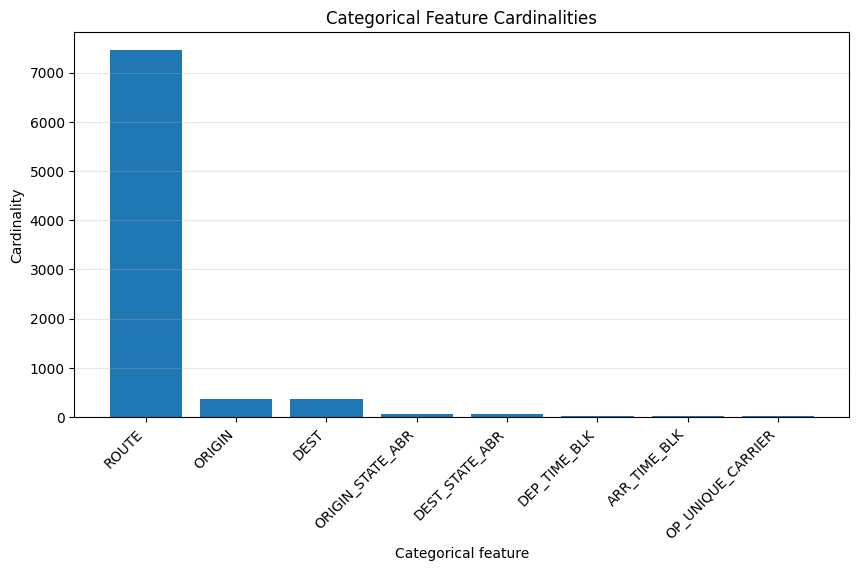

In [23]:
plt.figure(figsize=(10, 5))
plt.bar(
    categorical_feature_table["feature"],
    categorical_feature_table["cardinality"]
)
plt.xlabel("Categorical feature")
plt.ylabel("Cardinality")
plt.title("Categorical Feature Cardinalities")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
save_current_figure("figure_08_categorical_feature_cardinalities.png")
plt.show()

### Cardinality Interpretation

`ROUTE` has the largest cardinality by far. This makes one-hot encoding inefficient and supports the use of embeddings and attention-based models that can learn dense route representations.


## Numerical Features

This table lists the scaled numerical features used by the models.

The numerical features include scheduled departure time (converted to minutes of day), sine and cosine transformations to represent cyclical patterns in time, month, and day of week, distance, and a weekend indicator. These features capture temporal and route information that is available before the flight, avoiding data leakage from actual arrival times.


In [24]:
numeric_feature_table = pd.DataFrame({
    "feature": numeric_cols,
    "type": "numerical_scaled"
})

save_table(numeric_feature_table, "table_09_numeric_features.csv")

numeric_feature_table

Saved table: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\tables\table_09_numeric_features.csv


,feature,type
0,DISTANCE,numerical_scaled
1,CRS_DEP_MINUTES_OF_DAY,numerical_scaled
2,dep_time_sin,numerical_scaled
3,dep_time_cos,numerical_scaled
4,month_sin,numerical_scaled
5,month_cos,numerical_scaled
6,day_of_week_sin,numerical_scaled
7,day_of_week_cos,numerical_scaled
8,is_weekend,numerical_scaled


### Numerical Feature Interpretation

The numerical feature set combines distance, scheduled time, cyclical calendar patterns, and weekend information. These features are all available before the flight, which helps avoid data leakage.


This feature engineering summary combines the categorical features, numerical features, and target definition into one table for the final report.


In [25]:
feature_engineering_summary = pd.DataFrame([
    {
        "feature_group": "Categorical features",
        "count": len(categorical_cols),
        "processing": "Integer encoding for embedding layers",
        "features": ", ".join(categorical_cols)
    },
    {
        "feature_group": "Numerical features",
        "count": len(numeric_cols),
        "processing": "StandardScaler normalization",
        "features": ", ".join(numeric_cols)
    },
    {
        "feature_group": "Target",
        "count": 1,
        "processing": "3-class delay severity classification",
        "features": target_col
    }
])

save_table(feature_engineering_summary, "table_10_feature_engineering_summary.csv")

feature_engineering_summary

Saved table: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\tables\table_10_feature_engineering_summary.csv


,feature_group,count,processing,features
0,Categorical features,8,Integer encoding for embedding layers,"OP_UNIQUE_CARRIER, ORIGIN, ORIGIN_STATE_ABR, D..."
1,Numerical features,9,StandardScaler normalization,"DISTANCE, CRS_DEP_MINUTES_OF_DAY, dep_time_sin..."
2,Target,1,3-class delay severity classification,delay_class


The final feature engineering setup gives each model the same input information. This makes the model comparison more fair because differences in performance come from the model architectures and training behavior, not different feature sets.


## Class Weights

Class weights are calculated from the training split. They reduce the dominance of the majority class and help the models pay more attention to `Delay` and `Long delay` examples.

Class weights do not fully solve imbalance, but they help stabilize training and make minority-class mistakes more important during optimization.


In [26]:
class_weights_table = pd.DataFrame({
    "class_id": [int(k) for k in class_weights_dict.keys()],
    "class_name": [class_names[str(k)] for k in class_weights_dict.keys()],
    "raw_class_weight": [float(v) for v in class_weights_dict.values()]
}).sort_values("class_id")

save_table(class_weights_table, "table_11_class_weights.csv")

class_weights_table

Saved table: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\tables\table_11_class_weights.csv


,class_id,class_name,raw_class_weight
0,0,On time,0.419549
1,1,Delay,2.080449
2,2,Long delay,7.362585


The class weight chart shows that the `Long delay` class receives the largest weight because it has the fewest examples.


Saved figure: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\figures\figure_09_raw_class_weights.png


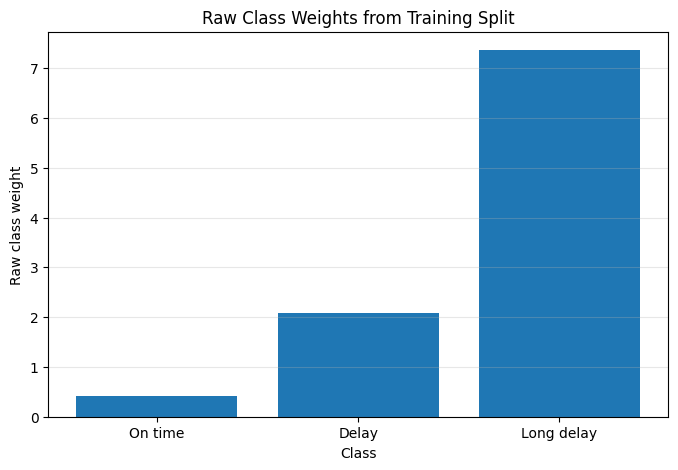

In [27]:
plt.figure(figsize=(8, 5))
plt.bar(class_weights_table["class_name"], class_weights_table["raw_class_weight"])
plt.xlabel("Class")
plt.ylabel("Raw class weight")
plt.title("Raw Class Weights from Training Split")
plt.grid(axis="y", alpha=0.3)
save_current_figure("figure_09_raw_class_weights.png")
plt.show()

### Class Weight Interpretation

The `Long delay` class receives the highest weight because it is the rarest class. The `On time` class receives the lowest weight because it is the majority class.


## Processed Dataset Shapes

PyTorch receives three arrays for each split:

- `X_cat` contains categorical IDs for embedding layers.
- `X_num` contains scaled numerical features.
- `y` contains the delay class.

This table confirms that the feature format is consistent across train, validation, and test.


In [28]:
train_data = np.load(PROCESSED_DIR / "train_data.npz")
val_data = np.load(PROCESSED_DIR / "val_data.npz")
test_data = np.load(PROCESSED_DIR / "test_data.npz")

processed_shapes = pd.DataFrame([
    {
        "split": "train",
        "X_cat_shape": str(train_data["X_cat"].shape),
        "X_num_shape": str(train_data["X_num"].shape),
        "y_shape": str(train_data["y"].shape)
    },
    {
        "split": "validation",
        "X_cat_shape": str(val_data["X_cat"].shape),
        "X_num_shape": str(val_data["X_num"].shape),
        "y_shape": str(val_data["y"].shape)
    },
    {
        "split": "test",
        "X_cat_shape": str(test_data["X_cat"].shape),
        "X_num_shape": str(test_data["X_num"].shape),
        "y_shape": str(test_data["y"].shape)
    }
])

save_table(processed_shapes, "table_12_processed_dataset_shapes.csv")

processed_shapes

Saved table: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\tables\table_12_processed_dataset_shapes.csv


,split,X_cat_shape,X_num_shape,y_shape
0,train,"(14411707, 8)","(14411707, 9)","(14411707,)"
1,validation,"(3088223, 8)","(3088223, 9)","(3088223,)"
2,test,"(3088224, 8)","(3088224, 9)","(3088224,)"


### Processed Shape Interpretation

The training set is larger than the validation and test sets due to the 70/15/15 stratified split. Each split keeps 8 categorical features and 9 numerical features (plus cyclical transforms), so the input structure is consistent across all splits.


## Model Results Overview

The final comparison includes three deep learning models:

1. MLP with Embeddings: the baseline neural model.
2. Wide & Deep Neural Network: combines direct numerical signals with deep feature interactions.
3. TabTransformer / FT-Transformer style model: uses self-attention over feature tokens.

The next cell loads the saved JSON result files from the training notebooks.


In [29]:
mlp_results = load_json(RESULTS_DIR / "mlp_embeddings_results.json")
wide_deep_results = load_json(RESULTS_DIR / "wide_deep_results.json")
tabtransformer_results = load_json(RESULTS_DIR / "tabtransformer_results.json")

mlp_results, wide_deep_results, tabtransformer_results

({'model_name': 'MLP with Embeddings',
  'test_loss': 0.9418475892728412,
  'test_accuracy': 0.716234962230719,
  'test_macro_f1': 0.4192354228963017,
  'test_weighted_f1': 0.7179429732255903,
  'best_val_macro_f1': 0.42020369785374356,
  'total_training_time_seconds': 3593.8418111801147,
  'num_epochs': 10,
  'batch_size': 4096,
  'optimizer': 'AdamW',
  'learning_rate': 0.001,
  'weight_decay': 0.0001,
  'loss_function': 'CrossEntropyLoss with softened class weights',
  'architecture': {'embedding_dims': [[16, 8],
    [363, 50],
    [53, 26],
    [363, 50],
    [53, 26],
    [7454, 50],
    [20, 10],
    [20, 10]],
   'hidden_dims': [256, 128, 64],
   'dropout': 0.3,
   'num_numeric_features': 9,
   'num_categorical_features': 8,
   'num_classes': 3}},
 {'model_name': 'Wide & Deep Neural Network',
  'test_loss': 0.975196366720491,
  'test_accuracy': 0.6538955723419027,
  'test_macro_f1': 0.4149294576408713,
  'test_weighted_f1': 0.68167669297424,
  'best_val_macro_f1': 0.415602898604

## Main Evaluation Metrics

The project reports several metrics:

- Accuracy measures overall correctness.
- Weighted F1 accounts for class support, so larger classes have more influence.
- Macro F1 gives equal importance to each class.

Macro F1 is the main metric because `Long delay` is a minority class. A model with high accuracy can still perform poorly on delayed flights.


In [30]:
model_comparison_rows = []

if mlp_results is not None:
    model_comparison_rows.append({
        "model": "MLP with Embeddings",
        "variant": "raw",
        "accuracy": mlp_results["test_accuracy"],
        "balanced_accuracy": None,
        "macro_f1": mlp_results["test_macro_f1"],
        "weighted_f1": mlp_results["test_weighted_f1"],
        "best_val_macro_f1": mlp_results["best_val_macro_f1"],
        "training_time_seconds": mlp_results["total_training_time_seconds"]
    })

if wide_deep_results is not None:
    model_comparison_rows.append({
        "model": "Wide & Deep",
        "variant": "raw",
        "accuracy": wide_deep_results["test_accuracy"],
        "balanced_accuracy": None,
        "macro_f1": wide_deep_results["test_macro_f1"],
        "weighted_f1": wide_deep_results["test_weighted_f1"],
        "best_val_macro_f1": wide_deep_results["best_val_macro_f1"],
        "training_time_seconds": wide_deep_results["total_training_time_seconds"]
    })

if tabtransformer_results is not None:
    raw_metrics = tabtransformer_results["raw_test_metrics"]
    calibrated_metrics = tabtransformer_results["calibrated_test_metrics"]
    
    model_comparison_rows.append({
        "model": "TabTransformer",
        "variant": "raw",
        "accuracy": raw_metrics["accuracy"],
        "balanced_accuracy": raw_metrics["balanced_accuracy"],
        "macro_f1": raw_metrics["macro_f1"],
        "weighted_f1": raw_metrics["weighted_f1"],
        "best_val_macro_f1": tabtransformer_results["best_val_macro_f1_raw"],
        "training_time_seconds": tabtransformer_results["total_training_time_seconds"]
    })
    
    model_comparison_rows.append({
        "model": "TabTransformer",
        "variant": "calibrated",
        "accuracy": calibrated_metrics["accuracy"],
        "balanced_accuracy": calibrated_metrics["balanced_accuracy"],
        "macro_f1": calibrated_metrics["macro_f1"],
        "weighted_f1": calibrated_metrics["weighted_f1"],
        "best_val_macro_f1": tabtransformer_results["best_val_macro_f1_raw"],
        "training_time_seconds": tabtransformer_results["total_training_time_seconds"]
    })

model_comparison = pd.DataFrame(model_comparison_rows)

model_comparison = model_comparison.sort_values(
    ["macro_f1", "weighted_f1"],
    ascending=False
)

save_table(model_comparison, "table_13_model_comparison_all_variants.csv")

model_comparison

Saved table: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\tables\table_13_model_comparison_all_variants.csv


,model,variant,accuracy,balanced_accuracy,macro_f1,weighted_f1,best_val_macro_f1,training_time_seconds
3,TabTransformer,calibrated,0.705704,0.442524,0.434613,0.715504,0.431400,10531.417439
2,TabTransformer,raw,0.734363,0.425908,0.430943,0.728393,0.431400,10531.417439
0,MLP with Embeddings,raw,0.716235,NaN,0.419235,0.717943,0.420204,3593.841811
1,Wide & Deep,raw,0.653896,NaN,0.414929,0.681677,0.415603,3269.170743


The all-variants table includes both raw and calibrated TabTransformer results. This is useful because it shows the effect of calibration before selecting the final TabTransformer version.


## Model Comparison

This table keeps one final version of each model for comparison:

- MLP with Embeddings, raw version.
- Wide & Deep, raw version.
- TabTransformer, calibrated version.

The calibrated TabTransformer is used because calibration improves class balance using validation data. The test set is not used to choose the calibration multipliers.


In [31]:
main_model_comparison = model_comparison[
    (
        ((model_comparison["model"] == "MLP with Embeddings") & (model_comparison["variant"] == "raw")) |
        ((model_comparison["model"] == "Wide & Deep") & (model_comparison["variant"] == "raw")) |
        ((model_comparison["model"] == "TabTransformer") & (model_comparison["variant"] == "calibrated"))
    )
].copy()

main_model_comparison = main_model_comparison.sort_values(
    "macro_f1",
    ascending=False
)

save_table(main_model_comparison, "table_14_main_model_comparison.csv")

main_model_comparison

Saved table: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\tables\table_14_main_model_comparison.csv


,model,variant,accuracy,balanced_accuracy,macro_f1,weighted_f1,best_val_macro_f1,training_time_seconds
3,TabTransformer,calibrated,0.705704,0.442524,0.434613,0.715504,0.431400,10531.417439
0,MLP with Embeddings,raw,0.716235,NaN,0.419235,0.717943,0.420204,3593.841811
1,Wide & Deep,raw,0.653896,NaN,0.414929,0.681677,0.415603,3269.170743


### Model Comparison Interpretation

The MLP achieves strong accuracy but struggles with minority classes. Wide & Deep increases prediction of delayed classes but does not improve over the MLP in Macro F1. The calibrated TabTransformer achieves the best Macro F1 by balancing predictions across all three classes, making it the selected final model.

This shows why the best model is not necessarily the one with the highest accuracy. The final ranking is based mainly on Macro F1 because the goal is balanced performance across all delay classes.


## Macro F1 Comparison

Macro F1 is the main ranking metric in this project. It better reflects whether the model can handle all three classes, not only the majority class.


Saved figure: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\figures\figure_10_model_macro_f1_comparison.png


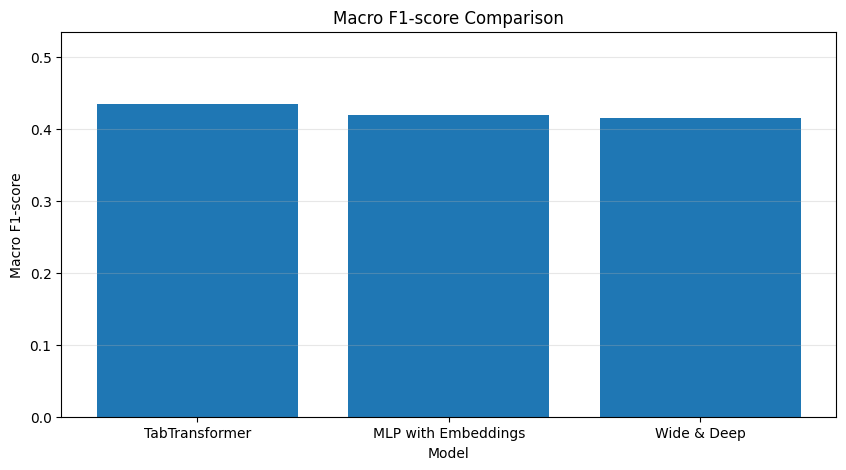

In [32]:
plt.figure(figsize=(10, 5))
plt.bar(
    main_model_comparison["model"],
    main_model_comparison["macro_f1"]
)
plt.xlabel("Model")
plt.ylabel("Macro F1-score")
plt.title("Macro F1-score Comparison")
plt.ylim(0, max(main_model_comparison["macro_f1"]) + 0.1)
plt.grid(axis="y", alpha=0.3)
save_current_figure("figure_10_model_macro_f1_comparison.png")
plt.show()

### Macro F1 Interpretation

The calibrated TabTransformer is the strongest model by Macro F1. The improvements over the other models reflect better overall balance across the three delay classes, particularly for the minority classes.


## Accuracy Comparison

Accuracy is still reported because it is easy to understand, but it is not the main metric for selecting the final model.


Saved figure: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\figures\figure_11_model_accuracy_comparison.png


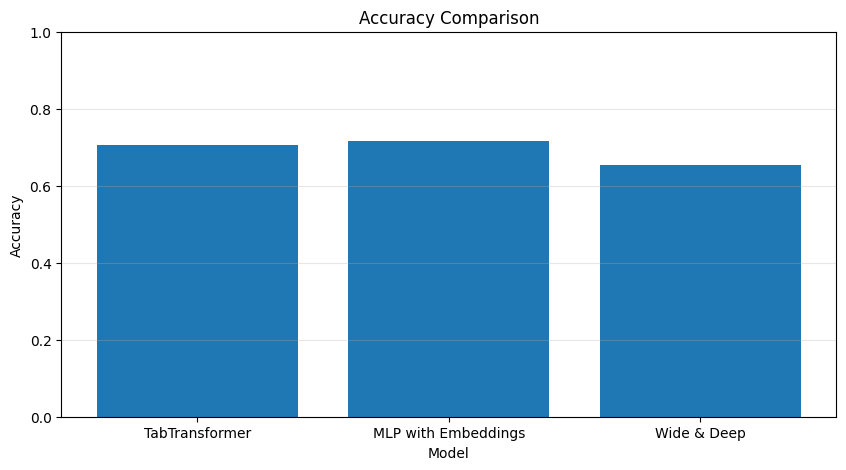

In [33]:
plt.figure(figsize=(10, 5))
plt.bar(
    main_model_comparison["model"],
    main_model_comparison["accuracy"]
)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
save_current_figure("figure_11_model_accuracy_comparison.png")
plt.show()

### Accuracy Interpretation

Accuracy favors models that classify the majority `On time` class well. The MLP has strong accuracy, but this does not mean it performs well on `Long delay`.


## Weighted F1 Comparison

Weighted F1 is useful as a general performance metric, but it is influenced by the majority class. For this project, Macro F1 is more important for judging balanced performance.


Saved figure: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\figures\figure_12_model_weighted_f1_comparison.png


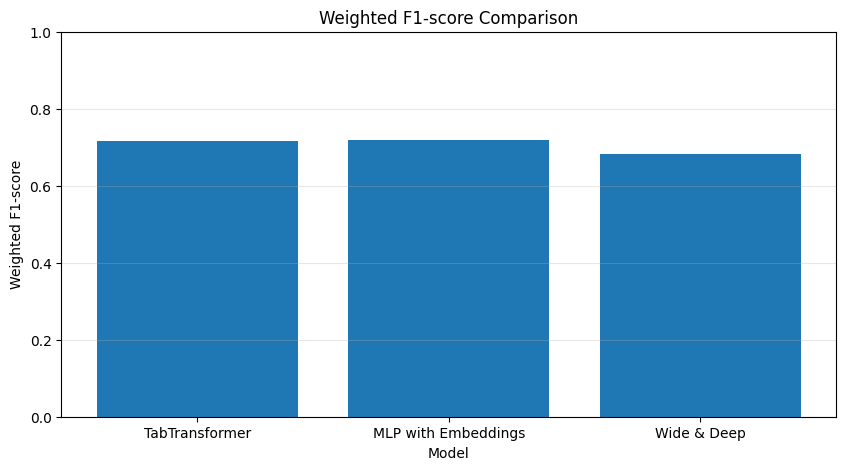

In [34]:
plt.figure(figsize=(10, 5))
plt.bar(
    main_model_comparison["model"],
    main_model_comparison["weighted_f1"]
)
plt.xlabel("Model")
plt.ylabel("Weighted F1-score")
plt.title("Weighted F1-score Comparison")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
save_current_figure("figure_12_model_weighted_f1_comparison.png")
plt.show()

### Weighted F1 Interpretation

Weighted F1 is close across the models because it is influenced by the large number of on-time flights. It is useful for context, but it is less important than Macro F1 for this project.


## Training Curves

Training histories are loaded to compare model behavior over epochs. These curves help check convergence, possible overfitting, and training stability.


In [35]:
history_files = {
    "MLP with Embeddings": RESULTS_DIR / "mlp_embeddings_training_history.csv",
    "Wide & Deep": RESULTS_DIR / "wide_deep_training_history.csv",
    "TabTransformer": RESULTS_DIR / "tabtransformer_training_history.csv"
}

history_frames = []

for model_name, path in history_files.items():
    if path.exists():
        hist = pd.read_csv(path)
        hist["model"] = model_name
        history_frames.append(hist)
    else:
        print(f"Missing history file: {path}")

all_histories = pd.concat(history_frames, ignore_index=True)

save_table(all_histories, "table_15_all_training_histories.csv")

all_histories.head()

Saved table: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\tables\table_15_all_training_histories.csv


,epoch,train_loss,train_accuracy,train_macro_f1,train_weighted_f1,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,epoch_time_seconds,model,train_balanced_accuracy,val_balanced_accuracy
0,1,0.964025,0.723887,0.386254,0.714062,0.952000,0.723506,0.401097,0.717411,376.941680,MLP with Embeddings,NaN,NaN
1,2,0.954471,0.723306,0.398332,0.716865,0.948740,0.729473,0.390435,0.719751,367.051279,MLP with Embeddings,NaN,NaN
2,3,0.951426,0.721714,0.402214,0.717149,0.946520,0.727929,0.409180,0.721596,378.662846,MLP with Embeddings,NaN,NaN
3,4,0.949340,0.721058,0.405337,0.717510,0.945163,0.726107,0.411608,0.721218,372.445958,MLP with Embeddings,NaN,NaN
4,5,0.947768,0.720193,0.407064,0.717539,0.944295,0.720925,0.410217,0.718763,360.179414,MLP with Embeddings,NaN,NaN


### Validation Macro F1 Curve

This curve shows how validation Macro F1 changes during training. It is useful because validation Macro F1 is the metric used for model selection.


Saved figure: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\figures\figure_13_validation_macro_f1_curves.png


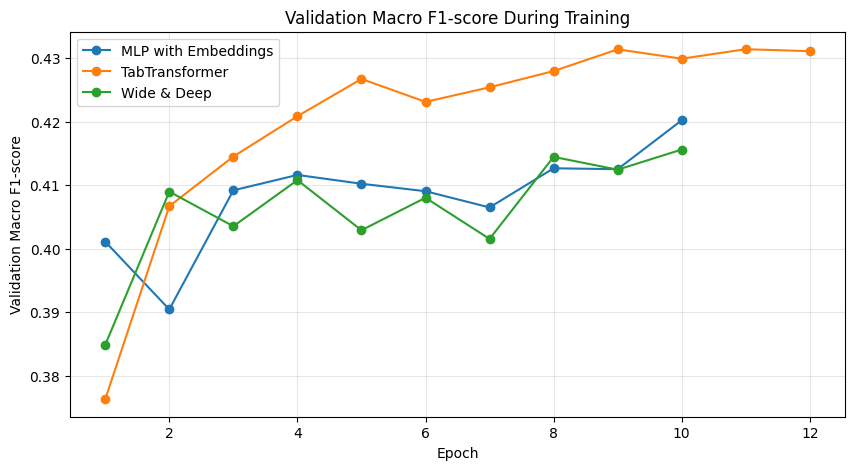

In [36]:
plt.figure(figsize=(10, 5))

for model_name, group in all_histories.groupby("model"):
    plt.plot(
        group["epoch"],
        group["val_macro_f1"],
        marker="o",
        label=model_name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Macro F1-score")
plt.title("Validation Macro F1-score During Training")
plt.legend()
plt.grid(True, alpha=0.3)
save_current_figure("figure_13_validation_macro_f1_curves.png")
plt.show()

### Validation Macro F1 Interpretation

The curves show that the models improve during training, but they do not all improve in the same way. The TabTransformer reaches its best validation Macro F1 early, while the MLP and Wide & Deep improve more gradually. This suggests that monitoring validation Macro F1 is necessary instead of relying only on the number of epochs.


### Validation Loss Curve

Validation loss is another way to monitor training. Lower validation loss is helpful, but Macro F1 remains more important for final selection because the class distribution is imbalanced.


Saved figure: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\figures\figure_14_validation_loss_curves.png


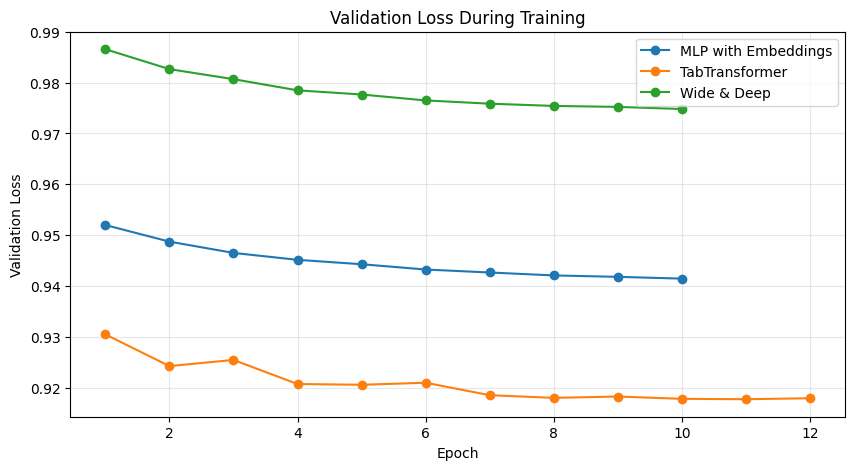

In [37]:
plt.figure(figsize=(10, 5))

for model_name, group in all_histories.groupby("model"):
    plt.plot(
        group["epoch"],
        group["val_loss"],
        marker="o",
        label=model_name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss During Training")
plt.legend()
plt.grid(True, alpha=0.3)
save_current_figure("figure_14_validation_loss_curves.png")
plt.show()

### Validation Loss Interpretation

Validation loss helps monitor training stability, but it does not fully describe class balance. For final selection, Macro F1 remains more appropriate because the target classes are imbalanced.


## Confusion Matrix Analysis

Confusion matrices show how predictions are distributed across classes. Rows are the true labels and columns are the predicted labels. The diagonal values are correct predictions.

The next cell loads the saved confusion matrices for the MLP, Wide & Deep, raw TabTransformer, and calibrated TabTransformer.


In [38]:
confusion_matrix_paths = {
    "MLP with Embeddings": RESULTS_DIR / "mlp_embeddings_confusion_matrix.csv",
    "Wide & Deep": RESULTS_DIR / "wide_deep_confusion_matrix.csv",
    "TabTransformer Raw": RESULTS_DIR / "tabtransformer_raw_confusion_matrix.csv",
    "TabTransformer Calibrated": RESULTS_DIR / "tabtransformer_calibrated_confusion_matrix.csv"
}

confusion_matrices = {}

for model_name, path in confusion_matrix_paths.items():
    if path.exists():
        confusion_matrices[model_name] = pd.read_csv(path, index_col=0)
    else:
        print(f"Missing confusion matrix: {path}")

confusion_matrices.keys()

dict_keys(['MLP with Embeddings', 'Wide & Deep', 'TabTransformer Raw', 'TabTransformer Calibrated'])

## Per-Class Performance

Average metrics can hide weak minority-class behavior. Per-class precision, recall, and F1-score show how each model behaves for `On time`, `Delay`, and `Long delay` separately.


In [39]:
def per_class_metrics_from_cm(cm_df, model_name):
    cm = cm_df.values.astype(float)
    
    support = cm.sum(axis=1)
    predicted = cm.sum(axis=0)
    tp = np.diag(cm)
    
    precision = np.divide(
        tp,
        predicted,
        out=np.zeros_like(tp),
        where=predicted != 0
    )
    
    recall = np.divide(
        tp,
        support,
        out=np.zeros_like(tp),
        where=support != 0
    )
    
    f1 = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(tp),
        where=(precision + recall) != 0
    )
    
    rows = []
    
    for idx, class_name in enumerate(cm_df.index):
        rows.append({
            "model": model_name,
            "class_name": class_name,
            "precision": precision[idx],
            "recall": recall[idx],
            "f1_score": f1[idx],
            "support": int(support[idx])
        })
    
    return pd.DataFrame(rows)


per_class_frames = []

for model_name, cm_df in confusion_matrices.items():
    per_class_frames.append(
        per_class_metrics_from_cm(cm_df, model_name)
    )

per_class_metrics = pd.concat(per_class_frames, ignore_index=True)

save_table(per_class_metrics, "table_16_per_class_metrics.csv")

per_class_metrics

Saved table: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\tables\table_16_per_class_metrics.csv


,model,class_name,precision,recall,f1_score,support
0,MLP with Embeddings,On time,0.842902,0.824970,0.833839,2453607
1,MLP with Embeddings,Delay,0.282279,0.357536,0.315481,494801
2,MLP with Embeddings,Long delay,0.180266,0.077488,0.108386,139816
3,Wide & Deep,On time,0.861049,0.717811,0.782933,2453607
4,Wide & Deep,Delay,0.255948,0.492651,0.336877,494801
5,Wide & Deep,Long delay,0.159154,0.102885,0.124978,139816
6,TabTransformer Raw,On time,0.839012,0.858746,0.848764,2453607
7,TabTransformer Raw,Delay,0.302820,0.288106,0.295280,494801
8,TabTransformer Raw,Long delay,0.172380,0.130872,0.148785,139816
9,TabTransformer Calibrated,On time,0.848163,0.810757,0.829038,2453607


The per-class table shows the main limitation of the project: `Long delay` remains difficult to detect. This is expected because it is rare and may depend on information not included in the pre-flight features.


### Per-Class F1-Score

This pivot table compares F1-score by class for the main models. It helps show which classes are easier or harder for each model.


In [40]:
main_per_class_metrics = per_class_metrics[
    per_class_metrics["model"].isin([
        "MLP with Embeddings",
        "Wide & Deep",
        "TabTransformer Calibrated"
    ])
].copy()

pivot_per_class_f1 = main_per_class_metrics.pivot(
    index="class_name",
    columns="model",
    values="f1_score"
).loc[target_names]

pivot_per_class_f1

model,MLP with Embeddings,TabTransformer Calibrated,Wide & Deep
class_name,,,
On time,0.833839,0.829038,0.782933
Delay,0.315481,0.307387,0.336877
Long delay,0.108386,0.167414,0.124978


The per-class F1 chart visualizes the same comparison. This is one of the most important figures for discussing model limitations.


Saved figure: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\figures\figure_15_per_class_f1_comparison.png


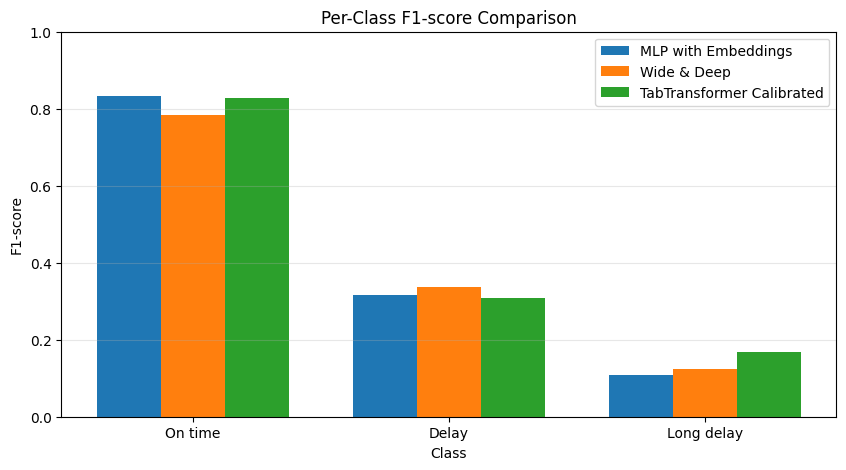

In [41]:
x = np.arange(len(target_names))
width = 0.25

plt.figure(figsize=(10, 5))

models_to_plot = ["MLP with Embeddings", "Wide & Deep", "TabTransformer Calibrated"]

for idx, model_name in enumerate(models_to_plot):
    plt.bar(
        x + (idx - 1) * width,
        pivot_per_class_f1[model_name],
        width,
        label=model_name
    )

plt.xlabel("Class")
plt.ylabel("F1-score")
plt.title("Per-Class F1-score Comparison")
plt.xticks(x, target_names)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)
save_current_figure("figure_15_per_class_f1_comparison.png")
plt.show()

### Per-Class F1 Interpretation

`On time` is the easiest class for all models. `Delay` is more difficult, and `Long delay` is the hardest class. The calibrated TabTransformer improves `Long delay` F1 compared with the simpler models, although the score is still limited.


### Per-Class Recall

Recall measures how many true examples of a class were detected by the model. This is important for delayed flights because low recall means many delays are missed.


In [42]:
pivot_per_class_recall = main_per_class_metrics.pivot(
    index="class_name",
    columns="model",
    values="recall"
).loc[target_names]

pivot_per_class_recall

model,MLP with Embeddings,TabTransformer Calibrated,Wide & Deep
class_name,,,
On time,0.824970,0.810757,0.717811
Delay,0.357536,0.331937,0.492651
Long delay,0.077488,0.184879,0.102885


The recall chart helps explain the trade-off between detecting more delayed flights and maintaining overall accuracy.


Saved figure: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\figures\figure_16_per_class_recall_comparison.png


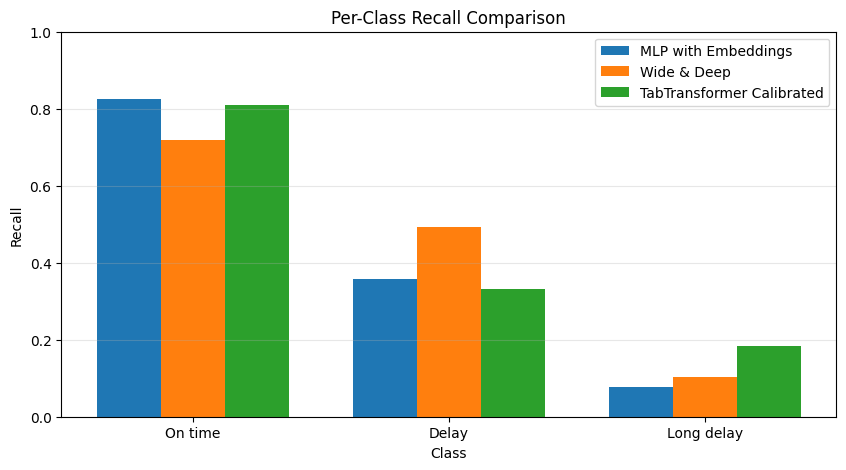

In [43]:
x = np.arange(len(target_names))
width = 0.25

plt.figure(figsize=(10, 5))

for idx, model_name in enumerate(models_to_plot):
    plt.bar(
        x + (idx - 1) * width,
        pivot_per_class_recall[model_name],
        width,
        label=model_name
    )

plt.xlabel("Class")
plt.ylabel("Recall")
plt.title("Per-Class Recall Comparison")
plt.xticks(x, target_names)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)
save_current_figure("figure_16_per_class_recall_comparison.png")
plt.show()

### Per-Class Recall Interpretation

Recall for `Long delay` is low across the models, which means many long delays are missed. The calibrated TabTransformer improves this recall compared with the MLP and Wide & Deep, but long-delay detection is still a clear limitation of the current feature set.


## Confusion Matrix Plot Function

This function plots raw or normalized confusion matrices. Raw matrices show counts, while normalized matrices show proportions within each true class.


In [44]:
def plot_confusion_matrix(cm_df, title, filename, normalize=False):
    cm = cm_df.values.astype(float)
    
    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        cm_plot = np.divide(
            cm,
            row_sums,
            out=np.zeros_like(cm),
            where=row_sums != 0
        )
    else:
        cm_plot = cm
    
    plt.figure(figsize=(8, 6))
    plt.imshow(cm_plot, interpolation="nearest")
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks(np.arange(len(cm_df.columns)), cm_df.columns, rotation=45)
    plt.yticks(np.arange(len(cm_df.index)), cm_df.index)
    
    for i in range(cm_plot.shape[0]):
        for j in range(cm_plot.shape[1]):
            if normalize:
                text = f"{cm_plot[i, j]:.2f}"
            else:
                text = f"{int(cm_plot[i, j]):,}"
            
            plt.text(j, i, text, ha="center", va="center")
    
    plt.colorbar()
    plt.tight_layout()
    save_current_figure(filename)
    plt.show()

### Raw Confusion Matrices

The next three figures show raw counts for the main models. They are useful for understanding the scale of correct and incorrect predictions.


Saved figure: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\figures\figure_17_mlp_confusion_matrix.png


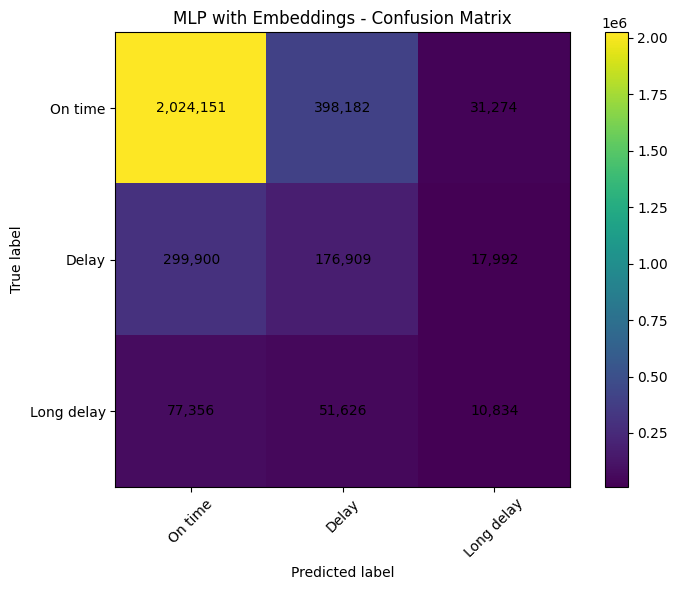

In [45]:
plot_confusion_matrix(
    confusion_matrices["MLP with Embeddings"],
    "MLP with Embeddings - Confusion Matrix",
    "figure_17_mlp_confusion_matrix.png",
    normalize=False
)

Saved figure: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\figures\figure_18_wide_deep_confusion_matrix.png


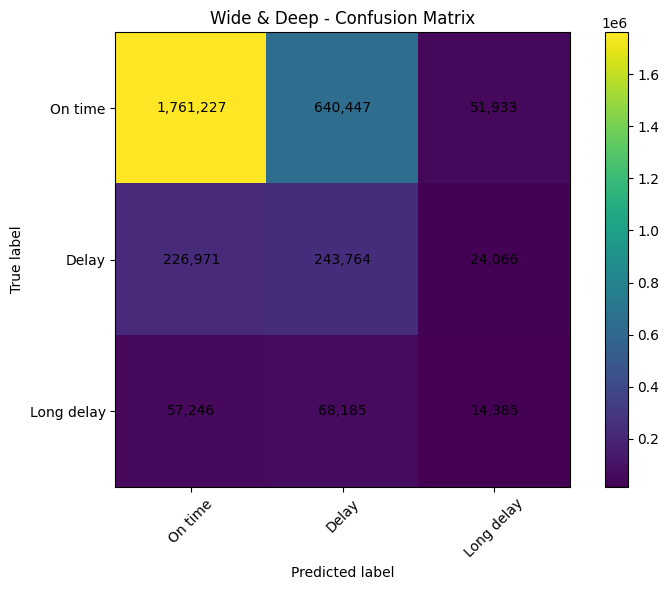

In [46]:
plot_confusion_matrix(
    confusion_matrices["Wide & Deep"],
    "Wide & Deep - Confusion Matrix",
    "figure_18_wide_deep_confusion_matrix.png",
    normalize=False
)

Saved figure: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\figures\figure_19_tabtransformer_calibrated_confusion_matrix.png


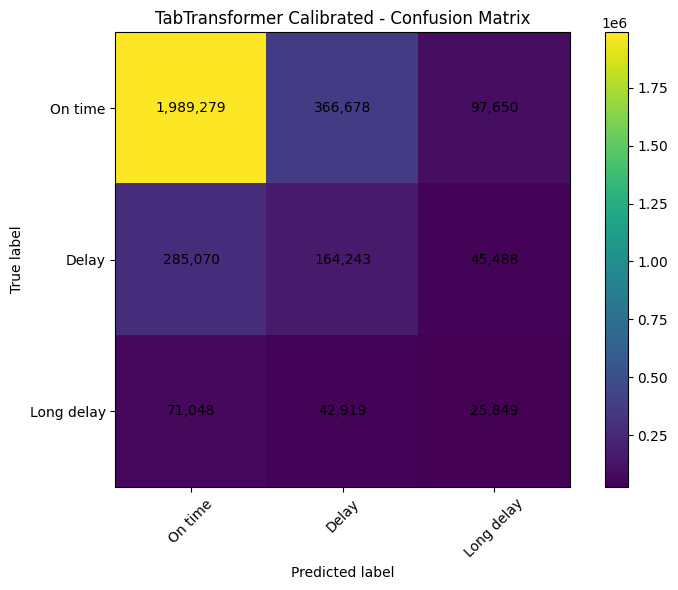

In [47]:
plot_confusion_matrix(
    confusion_matrices["TabTransformer Calibrated"],
    "TabTransformer Calibrated - Confusion Matrix",
    "figure_19_tabtransformer_calibrated_confusion_matrix.png",
    normalize=False
)

### Raw Confusion Matrix Interpretation

The MLP tends to favor `On time`, which explains its high accuracy and weak minority-class results. Wide & Deep predicts delayed classes more often. The calibrated TabTransformer gives the best overall balance, but many `Long delay` flights are still confused with `On time` or `Delay`.


### Normalized Confusion Matrices

Normalized confusion matrices make class behavior easier to compare because each row is converted into proportions.


Saved figure: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\figures\figure_20_mlp_normalized_confusion_matrix.png


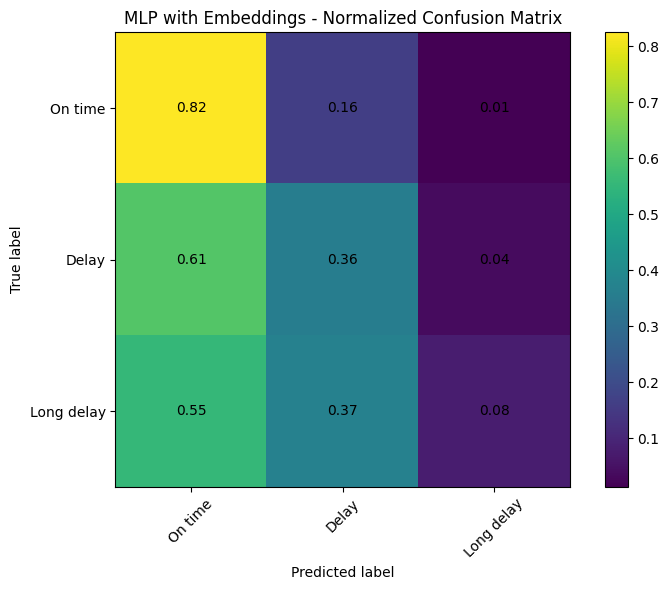

In [48]:
plot_confusion_matrix(
    confusion_matrices["MLP with Embeddings"],
    "MLP with Embeddings - Normalized Confusion Matrix",
    "figure_20_mlp_normalized_confusion_matrix.png",
    normalize=True
)

Saved figure: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\figures\figure_21_wide_deep_normalized_confusion_matrix.png


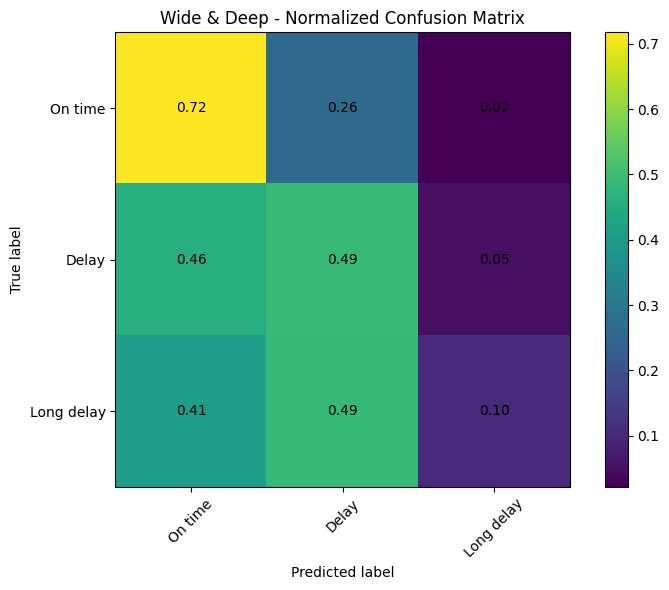

In [49]:
plot_confusion_matrix(
    confusion_matrices["Wide & Deep"],
    "Wide & Deep - Normalized Confusion Matrix",
    "figure_21_wide_deep_normalized_confusion_matrix.png",
    normalize=True
)

Saved figure: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\figures\figure_22_tabtransformer_calibrated_normalized_confusion_matrix.png


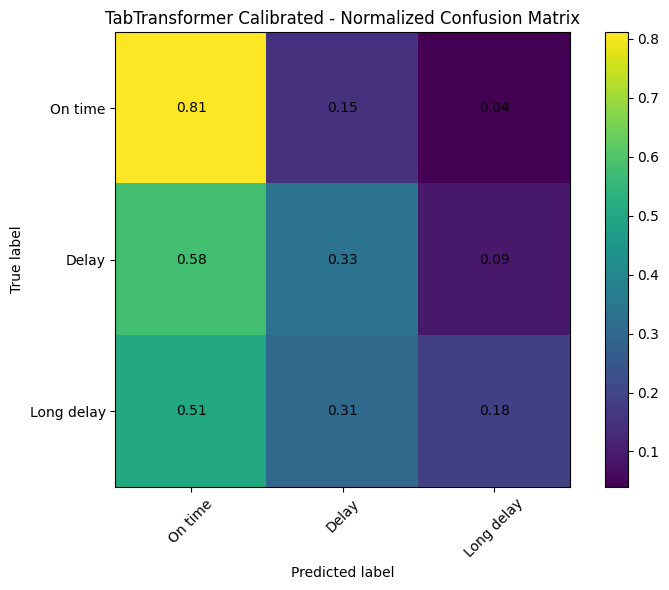

In [50]:
plot_confusion_matrix(
    confusion_matrices["TabTransformer Calibrated"],
    "TabTransformer Calibrated - Normalized Confusion Matrix",
    "figure_22_tabtransformer_calibrated_normalized_confusion_matrix.png",
    normalize=True
)

### Normalized Confusion Matrix Interpretation

The normalized matrices make the class trade-offs clearer. They show that the calibrated TabTransformer improves minority-class detection compared with the baseline, but the `Long delay` row still has many off-diagonal predictions. This is an important limitation to discuss in the final report.


## Final Paper Tables

The following tables are exported specifically for use in the final paper or report. They are compact versions of the main results and summaries.

### Paper Model Performance Table

This table reports the main metrics and training time for the final model comparison.


In [51]:
paper_model_table = main_model_comparison.copy()

paper_model_table = paper_model_table[
    [
        "model",
        "accuracy",
        "macro_f1",
        "weighted_f1",
        "best_val_macro_f1",
        "training_time_seconds"
    ]
]

paper_model_table["accuracy"] = paper_model_table["accuracy"].round(4)
paper_model_table["macro_f1"] = paper_model_table["macro_f1"].round(4)
paper_model_table["weighted_f1"] = paper_model_table["weighted_f1"].round(4)
paper_model_table["best_val_macro_f1"] = paper_model_table["best_val_macro_f1"].round(4)
paper_model_table["training_time_minutes"] = (
    paper_model_table["training_time_seconds"] / 60
).round(2)

paper_model_table = paper_model_table.drop(columns=["training_time_seconds"])

save_table(paper_model_table, "paper_table_01_model_performance.csv")

paper_model_table

Saved table: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\tables\paper_table_01_model_performance.csv


,model,accuracy,macro_f1,weighted_f1,best_val_macro_f1,training_time_minutes
3,TabTransformer,0.7057,0.4346,0.7155,0.4314,175.52
0,MLP with Embeddings,0.7162,0.4192,0.7179,0.4202,59.90
1,Wide & Deep,0.6539,0.4149,0.6817,0.4156,54.49


The paper model table is the main performance table for the report. It shows that the calibrated TabTransformer ranks first by Macro F1, while the MLP still has the highest accuracy.


### Paper Class Distribution Table

This compact table reports the final target distribution and is useful for explaining why class imbalance matters.


In [52]:
paper_class_distribution = overall_class_distribution.copy()

paper_class_distribution = paper_class_distribution[
    ["delay_class", "delay_class_name", "count", "percentage"]
]

paper_class_distribution["percentage"] = paper_class_distribution["percentage"].round(2)

save_table(paper_class_distribution, "paper_table_02_class_distribution.csv")

paper_class_distribution

Saved table: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\tables\paper_table_02_class_distribution.csv


,delay_class,delay_class_name,count,percentage
0,0,On time,16357376,79.45
1,1,Delay,3298671,16.02
2,2,Long delay,932107,4.53


The class distribution table is useful for explaining the evaluation strategy. It shows why Macro F1 and class-aware interpretation are needed.


### Paper Feature Table

This table summarizes the categorical and numerical features used by the models.


In [53]:
paper_feature_table = pd.DataFrame([
    {
        "feature_type": "Categorical",
        "num_features": len(categorical_cols),
        "features": ", ".join(categorical_cols)
    },
    {
        "feature_type": "Numerical",
        "num_features": len(numeric_cols),
        "features": ", ".join(numeric_cols)
    }
])

save_table(paper_feature_table, "paper_table_03_features.csv")

paper_feature_table

Saved table: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\tables\paper_table_03_features.csv


,feature_type,num_features,features
0,Categorical,8,"OP_UNIQUE_CARRIER, ORIGIN, ORIGIN_STATE_ABR, D..."
1,Numerical,9,"DISTANCE, CRS_DEP_MINUTES_OF_DAY, dep_time_sin..."


The feature table gives a compact view of the final inputs. It also makes clear that the models use only pre-flight information.


## Final Model Ranking

The final ranking is based on Macro F1 because it is the fairest metric for this imbalanced multiclass task.


In [54]:
final_ranking = main_model_comparison.copy()

final_ranking["rank_by_macro_f1"] = final_ranking["macro_f1"].rank(
    ascending=False,
    method="dense"
).astype(int)

final_ranking = final_ranking.sort_values("rank_by_macro_f1")

save_table(final_ranking, "paper_table_04_final_model_ranking.csv")

final_ranking

Saved table: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\tables\paper_table_04_final_model_ranking.csv


,model,variant,accuracy,balanced_accuracy,macro_f1,weighted_f1,best_val_macro_f1,training_time_seconds,rank_by_macro_f1
3,TabTransformer,calibrated,0.705704,0.442524,0.434613,0.715504,0.431400,10531.417439,1
0,MLP with Embeddings,raw,0.716235,NaN,0.419235,0.717943,0.420204,3593.841811,2
1,Wide & Deep,raw,0.653896,NaN,0.414929,0.681677,0.415603,3269.170743,3


### Final Ranking Interpretation

The calibrated TabTransformer is selected as the final model because it achieved the highest Macro F1-score. This model provides the best balance across all three delay classes while improving minority-class detection compared to simpler approaches. However, the model still has limitations, especially for predicting `Long delay` flights, which depend on factors not captured in pre-flight schedule and airline information.


## Final Results Summary

The next cell generates a short text summary for the report using the best model from the final ranking.


In [55]:
best_model_row = final_ranking.iloc[0]

best_model_name = best_model_row["model"]
best_macro_f1 = best_model_row["macro_f1"]
best_accuracy = best_model_row["accuracy"]
best_weighted_f1 = best_model_row["weighted_f1"]

summary_text = f"""
Final Results Summary

The best-performing model based on Macro F1-score was {best_model_name}.
It achieved an accuracy of {best_accuracy:.4f}, a Macro F1-score of {best_macro_f1:.4f}, and a Weighted F1-score of {best_weighted_f1:.4f}.

Macro F1-score was selected as the main evaluation metric because the dataset presents class imbalance across delay severity classes. Accuracy alone is not sufficient, since a model can achieve high accuracy by favoring the majority class.

The results show that more structured deep learning architectures improved class balance compared to the baseline MLP. In particular, the attention-based TabTransformer model provided the best trade-off between overall performance and minority-class detection.
"""

print(summary_text)

with open(REPORT_DIR / "final_results_summary.txt", "w") as f:
    f.write(summary_text)


Final Results Summary

The best-performing model based on Macro F1-score was TabTransformer.
It achieved an accuracy of 0.7057, a Macro F1-score of 0.4346, and a Weighted F1-score of 0.7155.

Macro F1-score was selected as the main evaluation metric because the dataset presents class imbalance across delay severity classes. Accuracy alone is not sufficient, since a model can achieve high accuracy by favoring the majority class.

The results show that more structured deep learning architectures improved class balance compared to the baseline MLP. In particular, the attention-based TabTransformer model provided the best trade-off between overall performance and minority-class detection.



### Final Results Interpretation

The generated summary correctly identifies the calibrated TabTransformer as the best model by Macro F1. It is important to describe this as the best model among the tested approaches, not as a perfect predictor.


## Generated Tables and Figures

This section lists all tables and figures exported by the notebook. These files are the main artifacts used in the final paper.


In [56]:
generated_tables = sorted(TABLES_DIR.glob("*.csv"))
generated_figures = sorted(FIGURES_DIR.glob("*.png"))

print("Generated tables:")
for table in generated_tables:
    print(table.name)

print("\nGenerated figures:")
for fig in generated_figures:
    print(fig.name)

Generated tables:
paper_table_01_model_performance.csv
paper_table_02_class_distribution.csv
paper_table_03_features.csv
paper_table_04_final_model_ranking.csv
table_01_dataset_overview.csv
table_02_monthly_flight_counts.csv
table_03_overall_class_distribution.csv
table_04_split_class_distribution.csv
table_05_carrier_delay_summary.csv
table_06_origin_delay_summary.csv
table_07_route_delay_summary.csv
table_08_categorical_feature_cardinalities.csv
table_09_numeric_features.csv
table_10_feature_engineering_summary.csv
table_11_class_weights.csv
table_12_processed_dataset_shapes.csv
table_13_model_comparison_all_variants.csv
table_14_main_model_comparison.csv
table_15_all_training_histories.csv
table_16_per_class_metrics.csv

Generated figures:
figure_01_monthly_flight_counts.png
figure_02_overall_class_distribution.png
figure_03_overall_class_distribution_percentage.png
figure_04_class_distribution_by_split.png
figure_05_top_carriers_avg_delay.png
figure_06_top_origin_airports_avg_delay

## Final Checklist

The final cell prints the main output folders and the recommended figures and tables for the report.


In [57]:
print("Notebook 06 completed.")

print("\nMain outputs:")
print("Tables directory:", TABLES_DIR)
print("Figures directory:", FIGURES_DIR)
print("Summary file:", REPORT_DIR / "final_results_summary.txt")

print("\nRecommended paper figures:")
recommended_figures = [
    "figure_02_overall_class_distribution.png",
    "figure_04_class_distribution_by_split.png",
    "figure_08_categorical_feature_cardinalities.png",
    "figure_10_model_macro_f1_comparison.png",
    "figure_13_validation_macro_f1_curves.png",
    "figure_15_per_class_f1_comparison.png",
    "figure_16_per_class_recall_comparison.png",
    "figure_22_tabtransformer_calibrated_normalized_confusion_matrix.png"
]

for fig in recommended_figures:
    print(fig)

print("\nRecommended paper tables:")
recommended_tables = [
    "paper_table_01_model_performance.csv",
    "paper_table_02_class_distribution.csv",
    "paper_table_03_features.csv",
    "paper_table_04_final_model_ranking.csv"
]

for table in recommended_tables:
    print(table)

Notebook 06 completed.

Main outputs:
Tables directory: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\tables
Figures directory: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\figures
Summary file: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\paper_outputs\final_results_summary.txt

Recommended paper figures:
figure_02_overall_class_distribution.png
figure_04_class_distribution_by_split.png
figure_08_categorical_feature_cardinalities.png
figure_10_model_macro_f1_comparison.png
figure_13_validation_macro_f1_curves.png
figure_15_per_class_f1_comparison.png
figure_16_per_class_recall_comparison.png
figure_22_tabtransformer_calibrated_normalized_confusion_matrix.png

Recommended paper tables:
paper_table_01_model_performance.csv
paper_table_02_class_distribution.csv
paper_table_03_features.csv
paper_table_04_final_model_ranking.csv


## Final Conclusion

This project built a scalable deep learning pipeline for flight delay severity prediction using a large real-world 2023-2025 flight dataset with approximately 21 million records from the BTS TranStats source. Redefining the target from 5 classes to 3 classes improved training stability and made the classification problem more meaningful.

The MLP with embeddings provided a stable baseline with strong accuracy. The Wide & Deep model increased prediction of delayed classes but did not outperform the MLP in Macro F1. The calibrated TabTransformer achieved the best overall performance with a Macro F1 of 0.4346, ranking first among all models tested.

The main limitation remains that `Long delay` is difficult to predict using only pre-flight features such as schedule, carrier, airport, route, time, and distance. Missing external factors such as weather conditions, aircraft rotation information, airport congestion, maintenance issues, Air Traffic Control restrictions, and real-time operational disruptions likely contribute to long-delay prediction errors. Future improvements could incorporate these signals to better capture the operational context affecting flight delays.
